In [8]:
import numpy as np
import pandas as pd

In [9]:
# Surpress warnings:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

In [14]:
data = pd.read_csv("Data/iris_data.csv")
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [15]:
#Determine the following:

#The number of data points (rows). (Hint: check out the dataframe .shape attribute.)
#The column names. (Hint: check out the dataframe .columns attribute.)
#The data types for each column. (Hint: check out the dataframe .dtypes attribute.)

In [16]:
#Number of rows 
print(data.shape[0])

#Columns names
print(data.columns.tolist())

#Data types
print(data.dtypes)

150
['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


In [17]:
#Examine the species names and note that they all begin with 'Iris-'. Remove this portion of the name so the species name is shorter.
#Hint: there are multiple ways to do this, but you could use either the string processing methods or the apply method.

In [18]:
# The str method maps the following function to each entry as a string
data['species'] = data.species.str.replace('Iris-', '')
# alternatively
# data['species'] = data.species.apply(lambda r: r.replace('Iris-', ''))
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [19]:
#Determine the following:

#The number of each species present. (Hint: check out the series .value_counts method.)
#The mean, median, and quantiles and ranges (max-min) for each petal and sepal measurement.
#Hint: for the last question, the .describe method does have median, but it's not called median. It's the 50% quantile. .describe does not have range though, and in order to get the range, you will need to create a new entry in the .describe table, which is max - min.

In [20]:
#One way to count each species
data.species.value_counts()

setosa        50
versicolor    50
virginica     50
Name: species, dtype: int64

In [21]:
stats_df = data.describe()
stats_df.loc['range'] = stats_df.loc['max'] - stats_df.loc['min']

out_fields = ['mean','25%','50%','75%', 'range']
stats_df = stats_df.loc[out_fields]
stats_df.rename({'50%': 'median'}, inplace=True)
stats_df

,sepal_length,sepal_width,petal_length,petal_width
mean,5.843333,3.054,3.758667,1.198667
25%,5.100000,2.800,1.600000,0.300000
median,5.800000,3.000,4.350000,1.300000
75%,6.400000,3.300,5.100000,1.800000
range,3.600000,2.400,5.900000,2.400000


In [22]:
#Calculate the following for each species in a separate dataframe:

#The mean of each measurement (sepal_length, sepal_width, petal_length, and petal_width).
#The median of each of these measurements.
#Hint: you may want to use Pandas groupby method to group by species before calculating the statistic.

#If you finish both of these, try calculating both statistics (mean and median) in a single table (i.e. with a single groupby call). See the section of the Pandas documentation on applying multiple functions at once for a hint.

In [24]:
data.groupby('species').mean()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.418,1.464,0.244
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


In [25]:
data.groupby('species').median()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.0,3.4,1.50,0.2
versicolor,5.9,2.8,4.35,1.3
virginica,6.5,3.0,5.55,2.0


In [27]:
# applying multiple functions at once - 2 methods

data.groupby('species').agg(['mean', 'median'])  # passing a list of recognized strings
data.groupby('species').agg([np.mean, np.median])  # passing a list of explicit aggregation functions

sepal_length        sepal_width        petal_length         \
                   mean median        mean median         mean median   
species                                                                 
setosa            5.006    5.0       3.418    3.4        1.464   1.50   
versicolor        5.936    5.9       2.770    2.8        4.260   4.35   
virginica         6.588    6.5       2.974    3.0        5.552   5.55   

           petal_width         
                  mean median  
species                        
setosa           0.244    0.2  
versicolor       1.326    1.3  
virginica        2.026    2.0

In [28]:
#Make a scatter plot of sepal_length vs sepal_width using Matplotlib. Label the axes and give the plot a title.

In [29]:
import matplotlib.pyplot as plt
%matplotlib inline

[Text(0.5, 0, 'Sepal Length (cm)'),
 Text(0, 0.5, 'Sepal Width(cm)'),
 Text(0.5, 1.0, 'Sepal Lenght vs Width')]

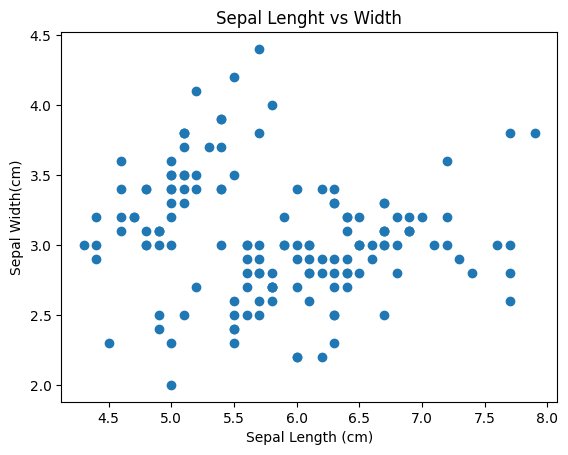

In [35]:
ax = plt.axes()
ax.scatter(data.sepal_length, data.sepal_width)

#labelling
ax.set(xlabel='Sepal Length (cm)',
      ylabel='Sepal Width(cm)',
       title='Sepal Lenght vs Width'
      );

In [31]:
#Make a histogram of any one of the four features. Label axes and title it as appropriate.

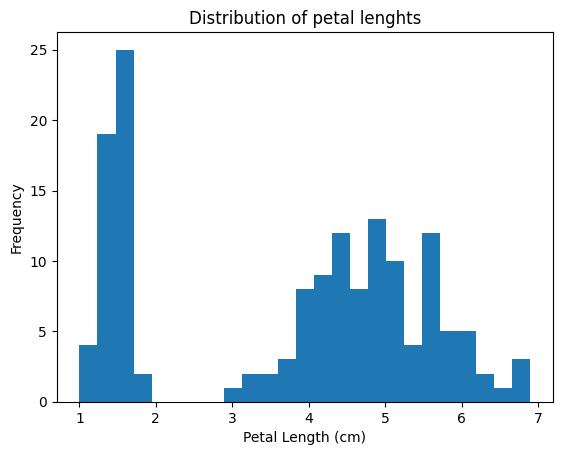

In [36]:
# Using Matplotlib's plotting functionality
ax = plt.axes()
ax.hist(data.petal_length, bins =25);

ax.set(
    xlabel = 'Petal Length (cm)',
    ylabel = 'Frequency',
    title = 'Distribution of petal lenghts'
);

[Text(0.5, 0, 'Petal length'),
 Text(0, 0.5, 'Frequwecy'),
 Text(0.5, 1.0, 'Distribution of petal lenghts')]

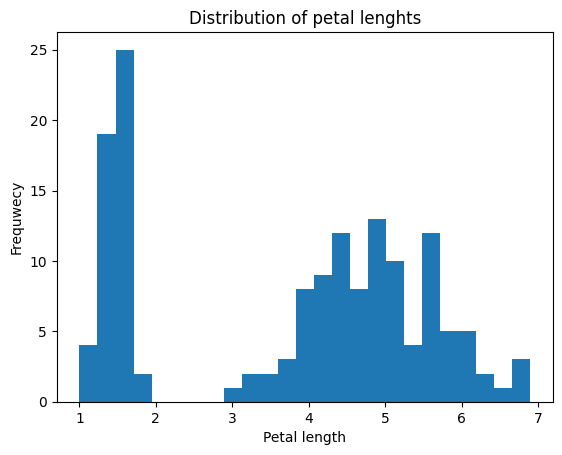

In [38]:
# Alternatively using Pandas plotting functionality
ax =data.petal_length.plot.hist(bins=25)

ax.set(xlabel = 'Petal length',
      ylabel = 'Frequwecy',
       title = 'Distribution of petal lenghts'
      )

In [39]:
#Now create a single plot with histograms for each feature (petal_width, petal_length, sepal_width, sepal_length) overlayed. If you have time, next try to create four individual histogram plots in a single figure, where each plot contains one feature.

#For some hints on how to do this with Pandas plotting methods, check out the visualization guide for Pandas.

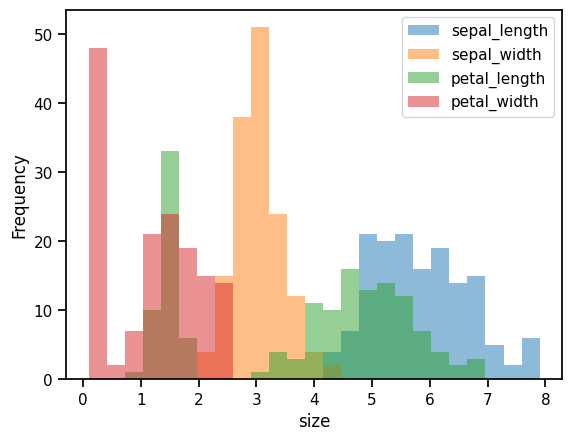

In [42]:
import seaborn as sns
sns.set_context('notebook')

ax = data.plot.hist(bins=25, alpha=0.5)
ax.set_xlabel('size');

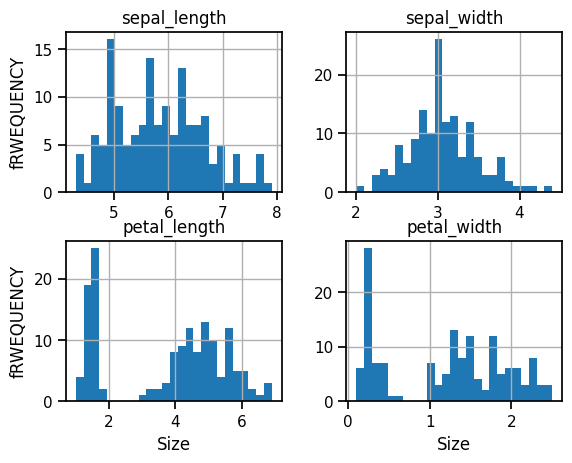

In [44]:
# To create four separate plots, use Pandas `.hist` method
axList= data.hist(bins=25)
# Add some x- and y- labels to first column and last row
for ax in axList.flatten():
    if ax.is_last_row():
        ax.set_xlabel('Size')
    if ax.is_first_col():
        ax.set_ylabel('fRWEQUENCY')




In [45]:
#Using Pandas, make a boxplot of each petal and sepal measurement. Here is the documentation for Pandas boxplot method.

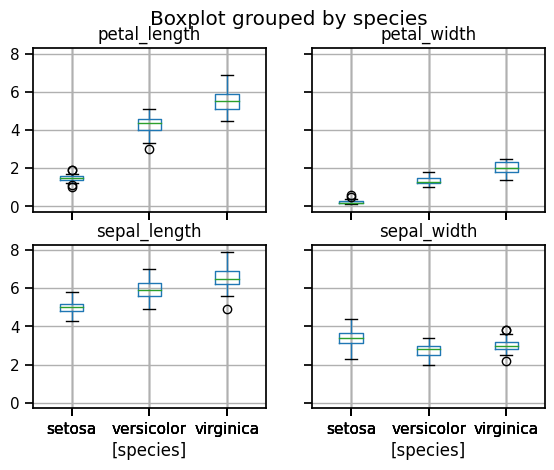

In [47]:
data.boxplot(by='species');

In [48]:
#Now make a single boxplot where the features are separated in the x-axis and species are colored with different hues.

#Hint: you may want to check the documentation for Seaborn boxplots.

In [60]:
# First we have to reshape the data so there is 
# only a single measurement in each column

plot_data = (data
             .set_index('species')
             .stack()
             .to_frame()
             .reset_index()
             .rename(columns={0:'size', 'level_1' :'measurement'})
)
plot_data.head()

,species,measurement,size
0,setosa,sepal_length,5.1
1,setosa,sepal_width,3.5
2,setosa,petal_length,1.4
3,setosa,petal_width,0.2
4,setosa,sepal_length,4.9


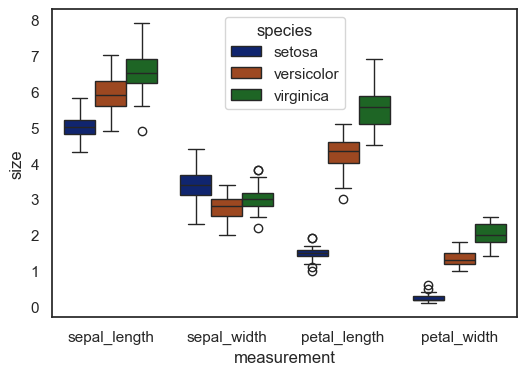

In [62]:
# Now plot the dataframe from above using Seaborn
sns.set_style('white')
sns.set_context('notebook')
sns.set_palette('dark')

f = plt.figure(figsize=(6,4))
sns.boxplot(x='measurement', y='size',
           hue='species', data= plot_data);

In [63]:
#Make a pairplot with Seaborn to examine the correlation between each of the measurements.

#Hint: this plot may look complicated, but it is actually only a single line of code. This is the power of Seaborn and dataframe-aware plotting! See the lecture notes for reference.

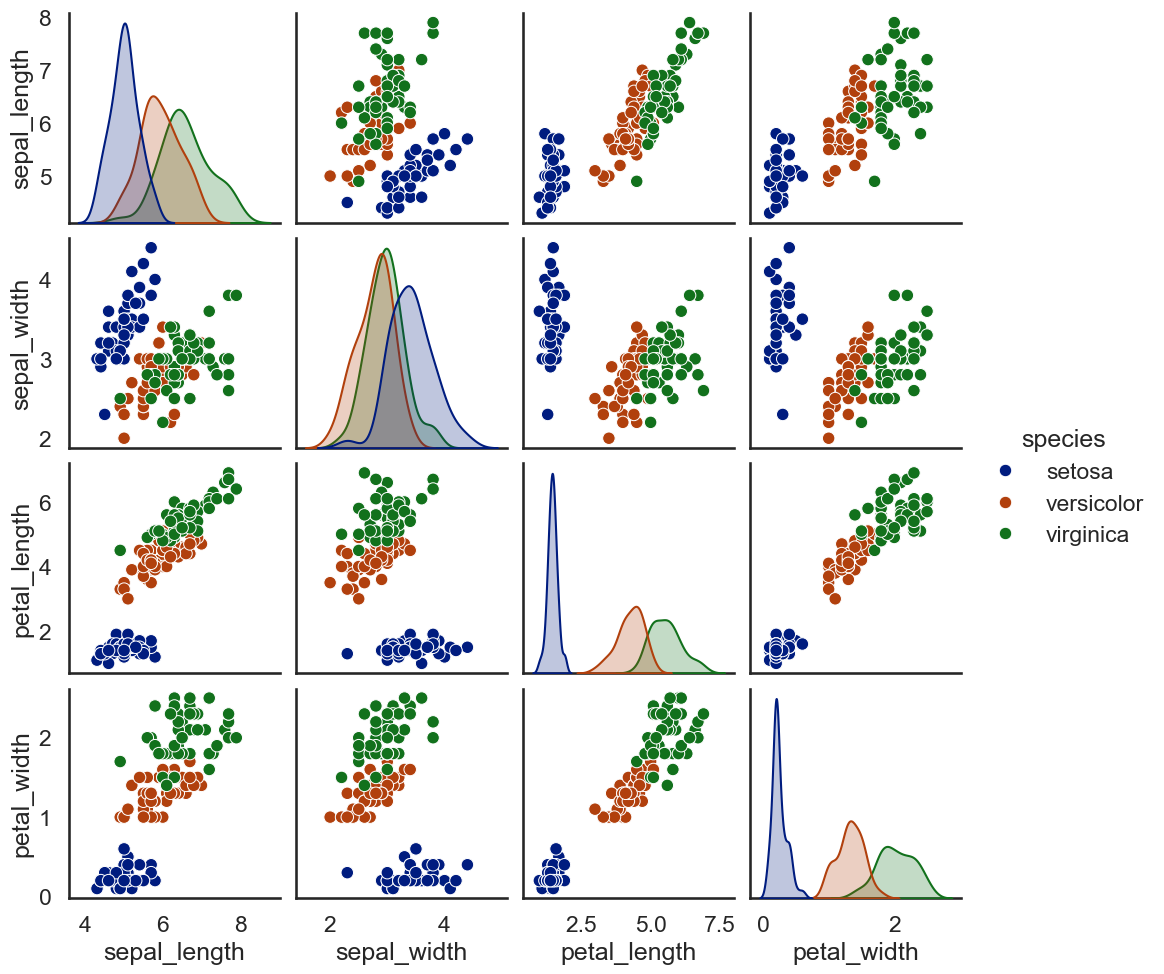

In [64]:
sns.set_context('talk')
sns.pairplot(data, hue='species');